In [151]:
import torch
import torchvision
import torchvision.transforms as transforms
from scipy.stats import levy_stable
from torch.utils.data import DataLoader, TensorDataset

In [152]:
import torchvision
import torchvision.transforms as transforms

def get_mnist_data():
    # 1. Define transformation to flatten the 28x28 images into a 784 vector
    # and normalize pixel values to [0, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: torch.flatten(x))
    ])
    
    # 2. Download Training and Testing sets
    train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    # 3. Extract tensors directly for your full-batch experiment
    X_train = train_set.data.float() / 255.0
    X_train = X_train.view(-1, 28*28) # Shape: [60000, 784]
    y_train = train_set.targets        # Shape: [60000] (LongTensor for integers 0-9)
    
    X_test = test_set.data.float() / 255.0
    X_test = X_test.view(-1, 28*28)   # Shape: [10000, 784]
    y_test = test_set.targets          # Shape: [10000]
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = get_mnist_data()

In [188]:
train_dataset = TensorDataset(X_train, y_train.long())
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [173]:
import torch.nn as nn

class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        # Change input from 123 to 784; output from 1 to 10
        self.linear = nn.Linear(784, 10)
        
    def forward(self, x):
        return self.linear(x)

# model_sgd = MNISTModel()
# model_signsgd = MNISTModel()

model_mnist = MNISTModel()

In [174]:
# 2. (DEFINING THE MODEL) & NON-CONVEX LOSS
# class NonConvexLogisticRegression(nn.Module):
#     def __init__(self, input_dim):
#         super(NonConvexLogisticRegression, self).__init__()
#         self.linear = nn.Linear(input_dim, 1, bias=False)
        
#     def forward(self, X_train):
#         return self.linear(X_train).squeeze()

def non_convex_regularizer(model, lam=0.1, alpha=1.0):
    reg = 0
    for param in model.parameters():
        # Geman-McClure: sum( (lam * w^2) / (1 + alpha * w^2) )
        reg += torch.sum((lam * param**2) / (1 + alpha * param**2))
    return reg

In [175]:
# 3. NOISE GENERATION (Lévy / Heavy-Tailed)
def add_heavy_tailed_noise(grad, alpha_levy=1.5, scale=0.01):
    """
    alpha_levy: 2.0 is Gaussian, 1.0 is Cauchy (Heavier).
    The paper suggests alpha < 2 captures the 'spikes'.
    """
    noise = levy_stable.rvs(alpha_levy, 0, scale=scale, size=grad.shape)
    return grad + torch.from_numpy(noise).float()

In [176]:
# def calculate_accuracy(outputs, targets):
#     # outputs shape: [Batch, 10]
#     # Find the index of the highest logit for each sample
#     _, predictions = torch.max(outputs, dim=1)
#     correct = (predictions == targets).sum().item()
#     return (correct / len(targets)) * 100.0

def calculate_accuracy(outputs, targets):
    # Get the index of the max logit along the class dimension (dim=1)
    predictions = torch.argmax(outputs, dim=1)
    correct = (predictions == targets).sum().item()
    return (correct / len(targets)) * 100.0

In [189]:
# 4. TRAINING LOOP
def run_experiment(opt_type='sgd', alpha_levy=1.5, lr=0.01, epochs=100):
    # model = NonConvexLogisticRegression(123)

    # model_sgd = MNISTModel()      # If using the MNISTModel class from the previous step
    # model_signsgd = MNISTModel()    

    # model = model_mnist

    model = MNISTModel()

    criterion = nn.CrossEntropyLoss()
    losses = []
    accs = []
    grad_norms = []

    # # Initialize history trackers
    # sgd_loss_history = []
    # sgd_acc_history = []

    # signsgd_loss_history = []
    # signsgd_acc_history = []
        
    # --------------------------#
    # for epoch in range(epochs):
    #     # Full batch gradient for stability control, then add synthetic noise
    #     outputs = model(X_train)

    #     #regularizer
    #     loss_val = criterion(outputs, y_train.long()) + non_convex_regularizer(model)

    #     #without regularizer
    #     # loss_val = criterion(outputs, y_train)
    
        
    #     model.zero_grad()
    #     loss_val.backward()
        
    #     with torch.no_grad():
    #         for param in model.parameters():
    #             # Inject Heavy-Tailed Noise into the gradient
    #             noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                
    #             if opt_type == 'sgd':
    #                 param -= lr * noisy_grad
    #             elif opt_type == 'signsgd':
    #                 # DSignSGD Step: sign(grad + noise)
    #                 param -= lr * torch.sign(noisy_grad)
        
    #     losses.append(loss_val.item())

    #     # Inside your test loop:
    #     with torch.no_grad():
    #         test_outputs = model(X_test)
    #         test_acc = calculate_accuracy(test_outputs, y_test)

    #         accs.append(test_acc)
            
    #         print(f"Test Accuracy ({opt_type}) epoch {epoch}: {test_acc:.2f}%")
        
    # return losses, accs, model

    #-------------------------------#

    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # NEW: Loop over mini-batches
        for X_batch, y_batch in train_loader:
            
            # Forward pass on the batch, not the whole dataset
            outputs = model(X_batch)
            # loss_val = criterion(outputs, y_batch) + non_convex_regularizer(model)
            loss_val = criterion(outputs, y_batch)
            
            model.zero_grad()
            loss_val.backward()

            #-- grad sq. norm --#
            total_norm_sq = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    # Sum up the squared elements of the gradient vector
                    total_norm_sq += torch.sum(param.grad ** 2).item()
            
            # This is the ||∇f(w_t)||^2 for this iteration
            grad_norms.append(total_norm_sq)

            # -- . -- #
            
            # Apply your optimizer step to the batch gradients
            with torch.no_grad():
                for param in model.parameters():
                    noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                    
                    if opt_type == 'sgd':
                        param -= lr * noisy_grad
                    elif opt_type == 'signsgd':
                        param -= lr * torch.sign(noisy_grad)
                        
            epoch_loss += loss_val.item()
        
        # Record the average loss for this epoch
        losses.append(epoch_loss / len(train_loader))
        print(f"epoch loss ({opt_type}) epoch {epoch}: {epoch_loss / len(train_loader):.2f}")

        # --- EVALUATION BLOCK (Fixed to use 'model') ---
        with torch.no_grad():
            test_outputs = model(X_test)
            test_acc = calculate_accuracy(test_outputs, y_test)
            accs.append(test_acc)
            print(f"Test Accuracy ({opt_type}) epoch {epoch}: {test_acc:.2f}%")
            
    return losses, accs, grad_norms, model



In [160]:
import matplotlib.pyplot as plt

def plot_training_results(sgd_loss, sgd_acc, signsgd_loss, signsgd_acc, alpha_levy, batch_size):
    epochs = range(1, len(sgd_loss) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Left Plot: Loss per Epoch
    plt.subplot(1, 2, 1)
    plt.plot(epochs, sgd_loss, color='crimson', marker='o', label='SGD Loss')
    plt.plot(epochs, signsgd_loss, color='teal', marker='^', label='SignSGD Loss')
    plt.title(f'Training Loss per Epoch, (Noise ($\\alpha={alpha_levy}$)) (Batch Size {batch_size})', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.grid(alpha=0.3)
    plt.legend()
    
    # Right Plot: Accuracy per Epoch
    plt.subplot(1, 2, 2)
    plt.plot(epochs, sgd_acc, color='crimson', marker='o', linestyle='--', label='SGD Accuracy')
    plt.plot(epochs, signsgd_acc, color='teal', marker='^', linestyle='--', label='SignSGD Accuracy')
    plt.title(f'Test Accuracy per Epoch, (Noise ($\\alpha={alpha_levy}$)) (Batch Size {batch_size})', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

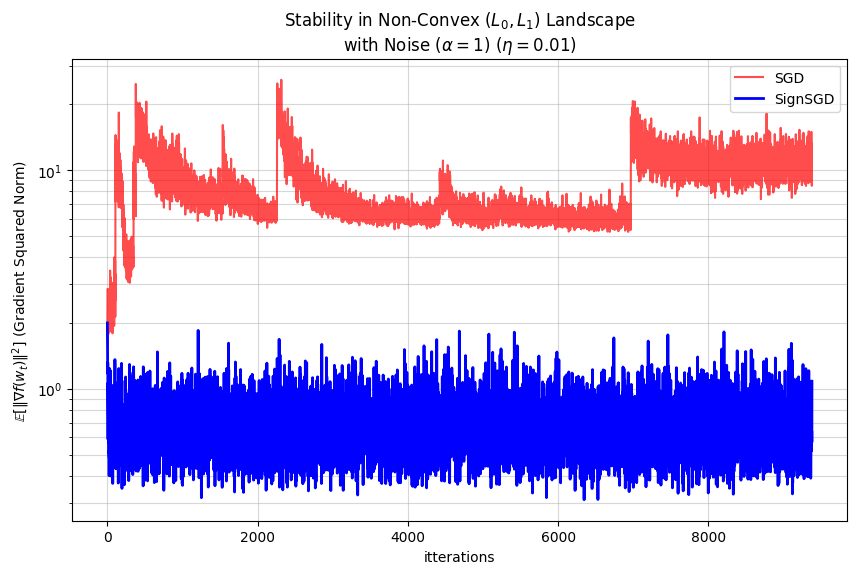

In [102]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_sgd, label='SGD', color='red', alpha=0.7)
plt.plot(grad_norms_signsgd, label='SignSGD', color='blue', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Stability in Non-Convex $(L_0, L_1)$ Landscape\nwith Noise ($\\alpha=1$) ($\\eta=0.01$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

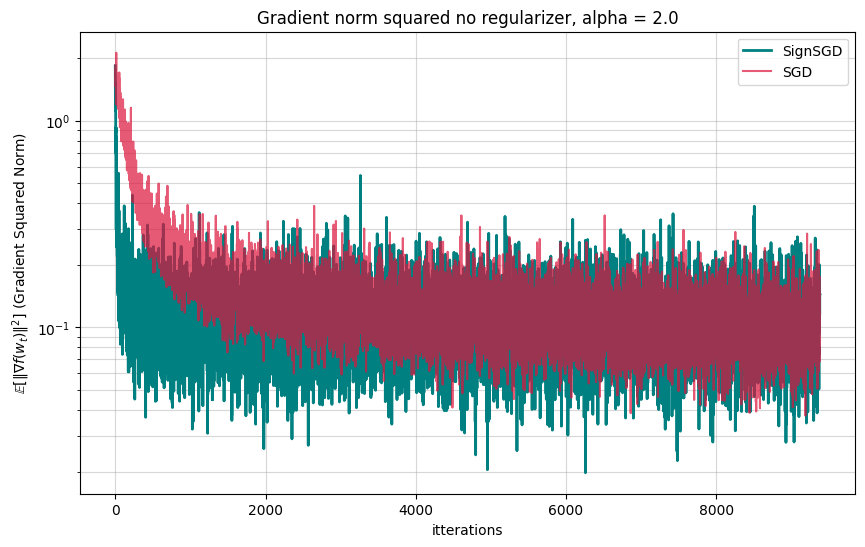

In [138]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared no regularizer, alpha = 2.0')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [190]:
# 5. RUNNING THE COMPARISON

# alpha = 2, lr = 0.01
print("Running Experiments...")
history_sgd_2, history_acc_sgd_2, grad_norms_sgd_2, model_sgd_2 = run_experiment(opt_type='sgd', alpha_levy=2, lr=0.01, epochs=50)
history_signsgd_2, history_acc_signsgd_2, grad_norms_signsgd_2, model_signsgd_2 = run_experiment(opt_type='signsgd', alpha_levy=2, lr=0.01, epochs=50)


Running Experiments...
epoch loss (sgd) epoch 0: 0.97
Test Accuracy (sgd) epoch 0: 86.91%
epoch loss (sgd) epoch 1: 0.55
Test Accuracy (sgd) epoch 1: 88.32%
epoch loss (sgd) epoch 2: 0.47
Test Accuracy (sgd) epoch 2: 89.21%
epoch loss (sgd) epoch 3: 0.43
Test Accuracy (sgd) epoch 3: 89.61%
epoch loss (sgd) epoch 4: 0.41
Test Accuracy (sgd) epoch 4: 90.00%
epoch loss (sgd) epoch 5: 0.39
Test Accuracy (sgd) epoch 5: 90.22%
epoch loss (sgd) epoch 6: 0.38
Test Accuracy (sgd) epoch 6: 90.42%
epoch loss (sgd) epoch 7: 0.37
Test Accuracy (sgd) epoch 7: 90.62%
epoch loss (sgd) epoch 8: 0.36
Test Accuracy (sgd) epoch 8: 90.67%
epoch loss (sgd) epoch 9: 0.36
Test Accuracy (sgd) epoch 9: 90.89%
epoch loss (sgd) epoch 10: 0.35
Test Accuracy (sgd) epoch 10: 90.97%
epoch loss (sgd) epoch 11: 0.34
Test Accuracy (sgd) epoch 11: 91.08%
epoch loss (sgd) epoch 12: 0.34
Test Accuracy (sgd) epoch 12: 91.16%
epoch loss (sgd) epoch 13: 0.34
Test Accuracy (sgd) epoch 13: 91.18%
epoch loss (sgd) epoch 14: 0.33

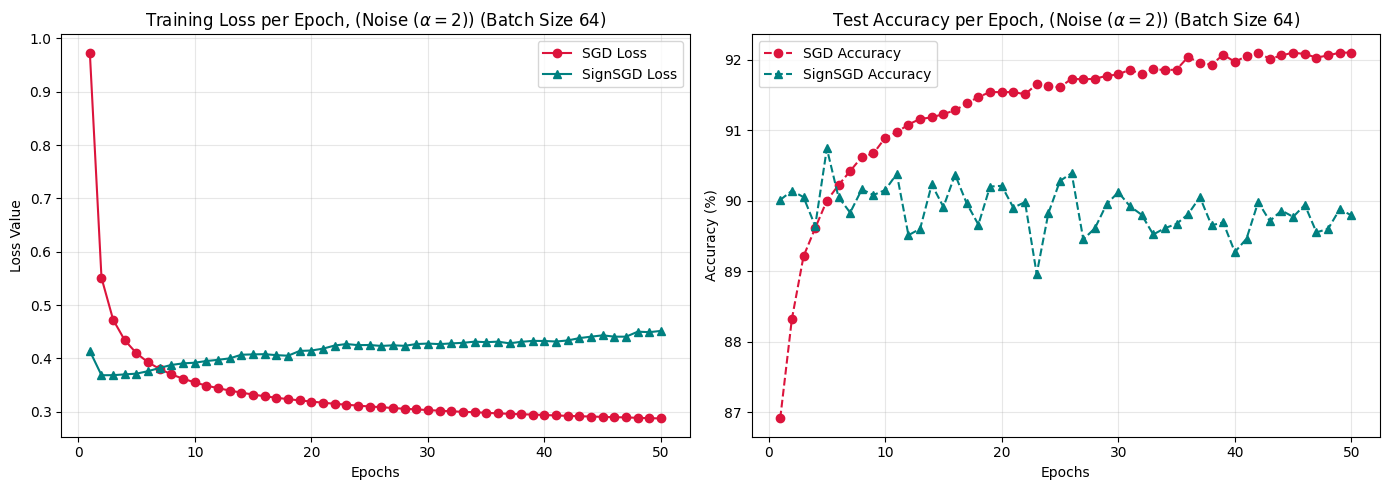

In [191]:
plot_training_results(history_sgd_2, history_acc_sgd_2, history_signsgd_2, history_acc_signsgd_2, 2, 64)

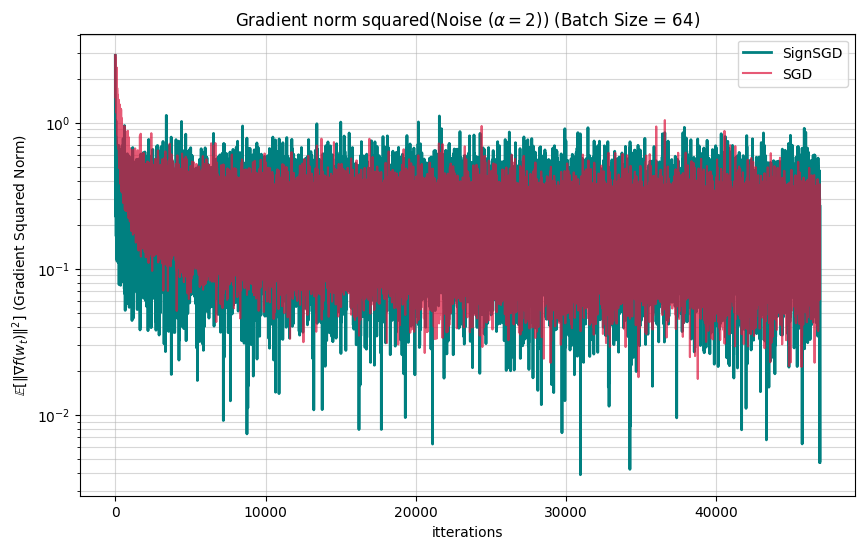

In [192]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd_2, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd_2, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared(Noise ($\\alpha={2}$)) (Batch Size = 64)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [193]:
# 5. RUNNING THE COMPARISON

# alpha = 1.4, lr = 0.01
print("Running Experiments...")
history_sgd_1_4, history_acc_sgd_1_4, grad_norms_sgd_1_4, model_sgd_1_4 = run_experiment(opt_type='sgd', alpha_levy=1.4, lr=0.01, epochs=50)
history_signsgd_1_4, history_acc_signsgd_1_4, grad_norms_signsgd_1_4, model_signsgd_1_4 = run_experiment(opt_type='signsgd', alpha_levy=1.4, lr=0.01, epochs=50)


Running Experiments...
epoch loss (sgd) epoch 0: 1.12
Test Accuracy (sgd) epoch 0: 81.00%
epoch loss (sgd) epoch 1: 0.64
Test Accuracy (sgd) epoch 1: 84.80%
epoch loss (sgd) epoch 2: 0.55
Test Accuracy (sgd) epoch 2: 85.56%
epoch loss (sgd) epoch 3: 0.53
Test Accuracy (sgd) epoch 3: 86.21%
epoch loss (sgd) epoch 4: 0.50
Test Accuracy (sgd) epoch 4: 86.74%
epoch loss (sgd) epoch 5: 0.48
Test Accuracy (sgd) epoch 5: 86.29%
epoch loss (sgd) epoch 6: 0.52
Test Accuracy (sgd) epoch 6: 84.72%
epoch loss (sgd) epoch 7: 0.62
Test Accuracy (sgd) epoch 7: 84.37%
epoch loss (sgd) epoch 8: 0.63
Test Accuracy (sgd) epoch 8: 81.91%
epoch loss (sgd) epoch 9: 0.61
Test Accuracy (sgd) epoch 9: 82.74%
epoch loss (sgd) epoch 10: 0.59
Test Accuracy (sgd) epoch 10: 84.08%
epoch loss (sgd) epoch 11: 0.57
Test Accuracy (sgd) epoch 11: 84.87%
epoch loss (sgd) epoch 12: 0.55
Test Accuracy (sgd) epoch 12: 85.46%
epoch loss (sgd) epoch 13: 0.55
Test Accuracy (sgd) epoch 13: 85.57%
epoch loss (sgd) epoch 14: 0.60

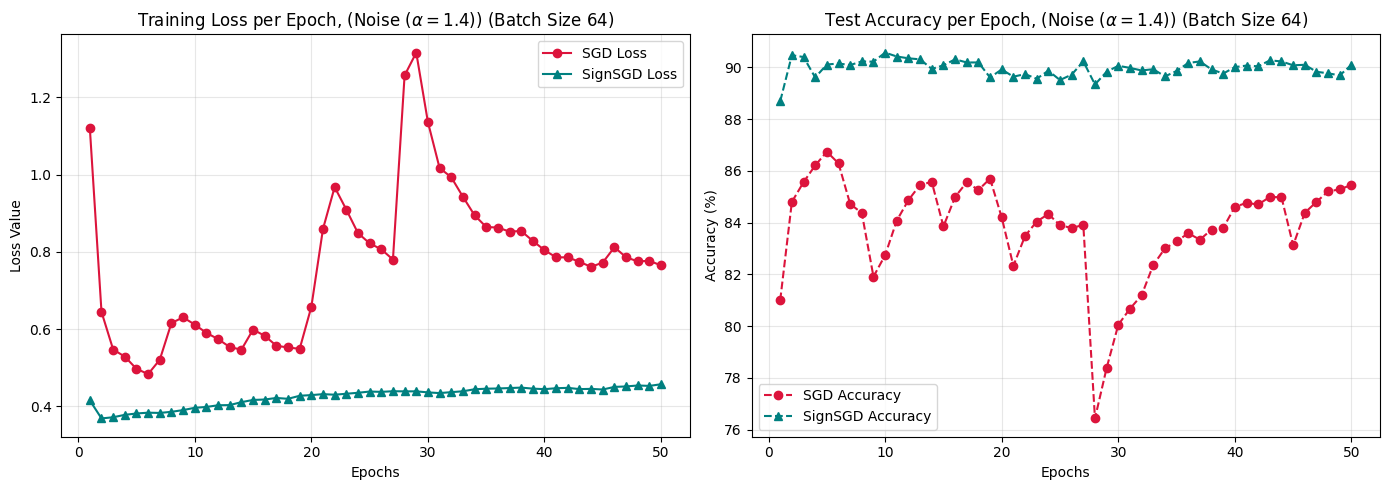

In [194]:
plot_training_results(history_sgd_1_4, history_acc_sgd_1_4, history_signsgd_1_4, history_acc_signsgd_1_4, 1.4, 64)

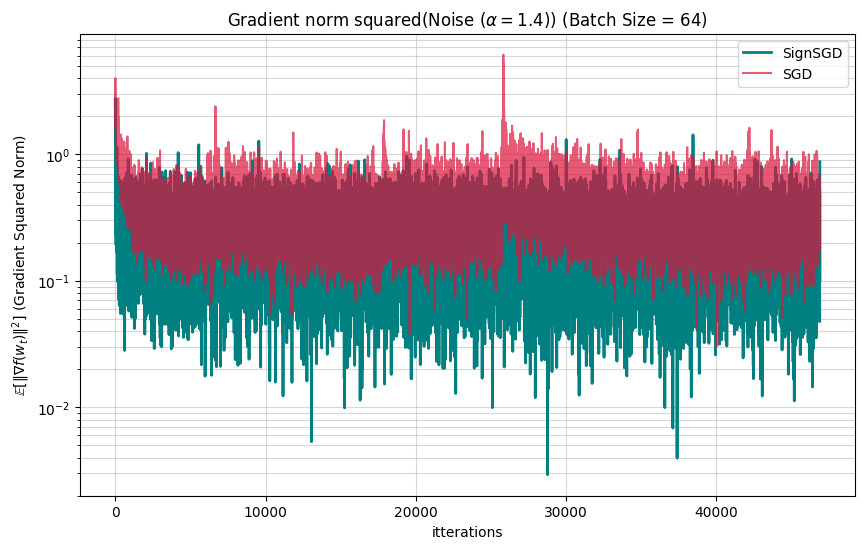

In [195]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd_1_4, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd_1_4, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared(Noise ($\\alpha={1.4}$)) (Batch Size = 64)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [196]:
# 5. RUNNING THE COMPARISON

# alpha = 1, lr = 0.01
print("Running Experiments...")
history_sgd_1, history_acc_sgd_1, grad_norms_sgd_1, model_sgd_1 = run_experiment(opt_type='sgd', alpha_levy=1, lr=0.01, epochs=50)
history_signsgd_1, history_acc_signsgd_1, grad_norms_signsgd_1, model_signsgd_1 = run_experiment(opt_type='signsgd', alpha_levy=1, lr=0.01, epochs=50)


Running Experiments...
epoch loss (sgd) epoch 0: 14.72
Test Accuracy (sgd) epoch 0: 29.40%
epoch loss (sgd) epoch 1: 120.16
Test Accuracy (sgd) epoch 1: 31.45%
epoch loss (sgd) epoch 2: 129.55
Test Accuracy (sgd) epoch 2: 32.85%
epoch loss (sgd) epoch 3: 139.24
Test Accuracy (sgd) epoch 3: 23.11%
epoch loss (sgd) epoch 4: 238.52
Test Accuracy (sgd) epoch 4: 13.45%
epoch loss (sgd) epoch 5: 228.70
Test Accuracy (sgd) epoch 5: 16.93%
epoch loss (sgd) epoch 6: 195.92
Test Accuracy (sgd) epoch 6: 21.13%
epoch loss (sgd) epoch 7: 173.20
Test Accuracy (sgd) epoch 7: 25.31%
epoch loss (sgd) epoch 8: 164.42
Test Accuracy (sgd) epoch 8: 28.23%
epoch loss (sgd) epoch 9: 157.33
Test Accuracy (sgd) epoch 9: 31.88%
epoch loss (sgd) epoch 10: 155.93
Test Accuracy (sgd) epoch 10: 34.20%
epoch loss (sgd) epoch 11: 161.28
Test Accuracy (sgd) epoch 11: 33.30%
epoch loss (sgd) epoch 12: 182.18
Test Accuracy (sgd) epoch 12: 30.10%
epoch loss (sgd) epoch 13: 185.13
Test Accuracy (sgd) epoch 13: 30.88%
epoc

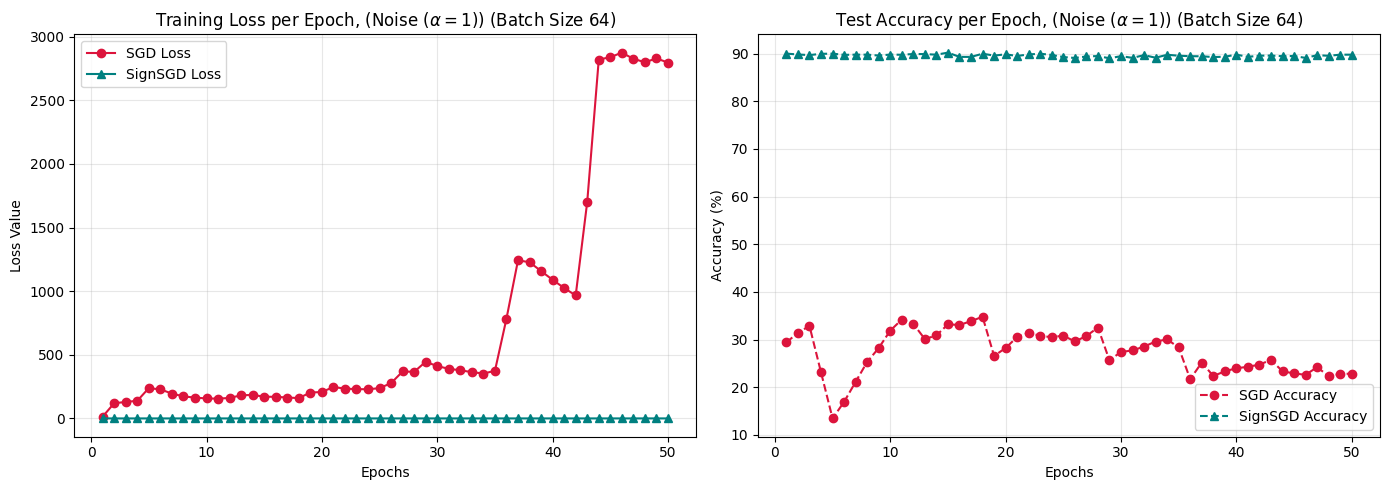

In [197]:
plot_training_results(history_sgd_1, history_acc_sgd_1, history_signsgd_1, history_acc_signsgd_1, 1, 64)

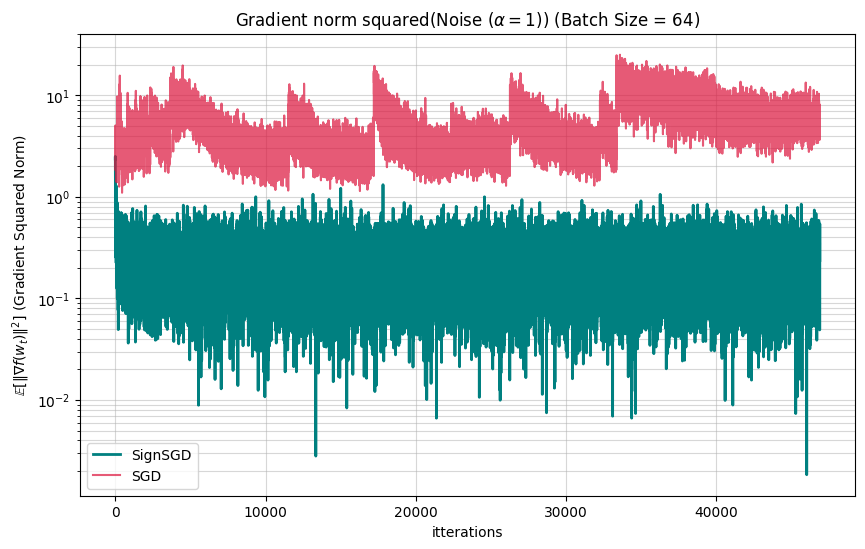

In [198]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd_1, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd_1, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared(Noise ($\\alpha={1}$)) (Batch Size = 64)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()